In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("single_genre_artists.csv")

In [3]:
print(df.shape)        
      
     


(95837, 23)


In [4]:
print(df.head()) 

                 id_songs         name_song  popularity_songs  duration_ms  \
0  0IA0Hju8CAgYfV1hwhidBH           La Java                 0       161427   
1  1b8HZQCqcqwbzlA1jRTp6E          En Douce                 0       223440   
2  5d5gQxHwYovxR5pqETOIAa     J'en Ai Marre                 0       208267   
3  1EO65UEEPfy7CR0NK2sDxy  Ils n'ont pas ca                 0       161933   
4  6a58gXSgqbIsXUhVZ6ZJqe         La belote                 0       167973   

   explicit              id_artists release_date  danceability  energy  key  \
0         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.563   0.184    4   
1         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.427   0.180   10   
2         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.511   0.206    0   
3         0  4AxgXfD7ISvJSTObqm4aIE         1924         0.676   0.467    9   
4         0  4AxgXfD7ISvJSTObqm4aIE         1924         0.650   0.298    9   

   ...  acousticness  instrumentalness  liveness  valenc

In [5]:
print(df.isnull().sum())

id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64


In [6]:
print(df.dtypes) 

id_songs               object
name_song              object
popularity_songs        int64
duration_ms             int64
explicit                int64
id_artists             object
release_date           object
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
followers             float64
genres                 object
name_artists           object
popularity_artists      int64
dtype: object


In [18]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop if any exist
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed! New shape: {df.shape}")
else:
    print("No duplicates found! ✅")

Number of duplicate rows: 0
No duplicates found! ✅


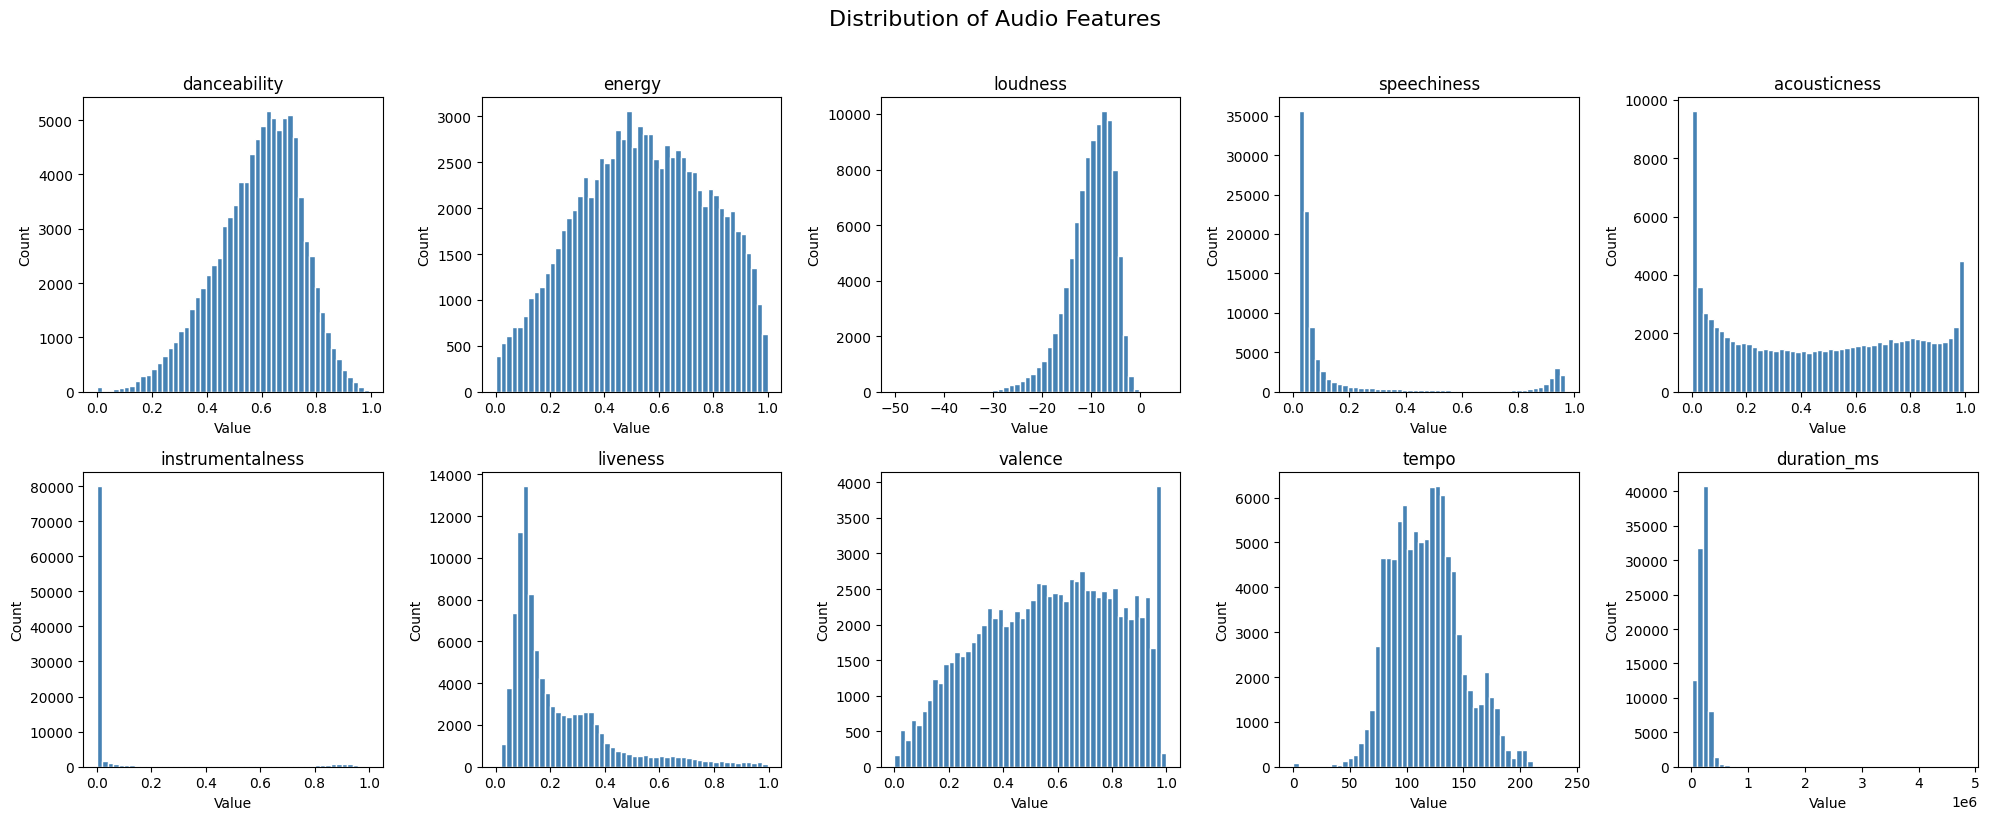

Distribution plots saved!


In [19]:
audio_features = ['danceability', 'energy', 'loudness', 
                   'speechiness', 'acousticness', 'instrumentalness',
                   'liveness', 'valence', 'tempo', 'duration_ms']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].hist(df[feature], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Audio Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution plots saved!")

In [7]:
# Columns to DROP (text IDs and non-audio info)
cols_to_drop = [
    'id_songs', 'name_song', 'id_artists', 
    'release_date', 'genres', 'name_artists',
    'explicit', 'key', 'mode', 'time_signature',
    'popularity_songs', 'popularity_artists', 
    'followers'
]


song_names = df['name_song'].copy()


df_features = df.drop(columns=cols_to_drop)

print(df_features.shape)
print(df_features.columns.tolist())
print(df_features.head())

(95837, 10)
['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
   duration_ms  danceability  energy  loudness  speechiness  acousticness  \
0       161427         0.563   0.184   -13.757       0.0512         0.993   
1       223440         0.427   0.180   -15.375       0.0670         0.989   
2       208267         0.511   0.206   -15.514       0.0592         0.995   
3       161933         0.676   0.467   -12.393       0.1650         0.991   
4       167973         0.650   0.298   -13.806       0.1380         0.991   

   instrumentalness  liveness  valence    tempo  
0          0.000016     0.325    0.654  133.088  
1          0.000000     0.128    0.431   78.459  
2          0.000000     0.418    0.481   70.443  
3          0.000000     0.219    0.726  129.775  
4          0.000000     0.373    0.844   75.950  


In [8]:
# NORMALIZATION 

In [9]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit and transform our features
# fit = learn the mean & std of each column
# transform = apply the scaling
df_scaled = scaler.fit_transform(df_features)

# Convert back to DataFrame so it's readable
df_scaled = pd.DataFrame(df_scaled, columns=df_features.columns)

print(df_scaled.describe().round(2))

       duration_ms  danceability    energy  loudness  speechiness  \
count     95837.00      95837.00  95837.00  95837.00     95837.00   
mean         -0.00          0.00      0.00      0.00        -0.00   
std           1.00          1.00      1.00      1.00         1.00   
min          -1.72         -3.78     -2.29     -8.43        -0.61   
25%          -0.44         -0.64     -0.75     -0.54        -0.49   
50%          -0.04          0.12      0.00      0.16        -0.45   
75%           0.35          0.73      0.79      0.73        -0.24   
max          38.99          2.60      1.94      3.27         2.90   

       acousticness  instrumentalness  liveness   valence     tempo  
count      95837.00          95837.00  95837.00  95837.00  95837.00  
mean          -0.00              0.00     -0.00      0.00     -0.00  
std            1.00              1.00      1.00      1.00      1.00  
min           -1.39             -0.35     -1.21     -2.31     -3.89  
25%           -0.99         

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia_values = []
silhouette_values = []
k_range = range(2, 11)  # test k from 2 to 10

for k in k_range:
    print(f"Testing k={k}...")  # so you can see progress
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(df_scaled, kmeans.labels_))

print("Done!")
print("Inertia values:", inertia_values)
print("Silhouette scores:", silhouette_values)

Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...
Testing k=10...
Done!
Inertia values: [778813.5948784597, 658335.0812701205, 593031.0334609612, 548594.9222401127, 520710.6045511209, 486936.3975328704, 460215.4065709421, 439036.6649942937, 415491.7311376387]
Silhouette scores: [0.20317003588832624, 0.24230720852804116, 0.2310082886552593, 0.18641404100206635, 0.15928069995727678, 0.18803090665208363, 0.16771321745013845, 0.16702513028002092, 0.17432876155757238]


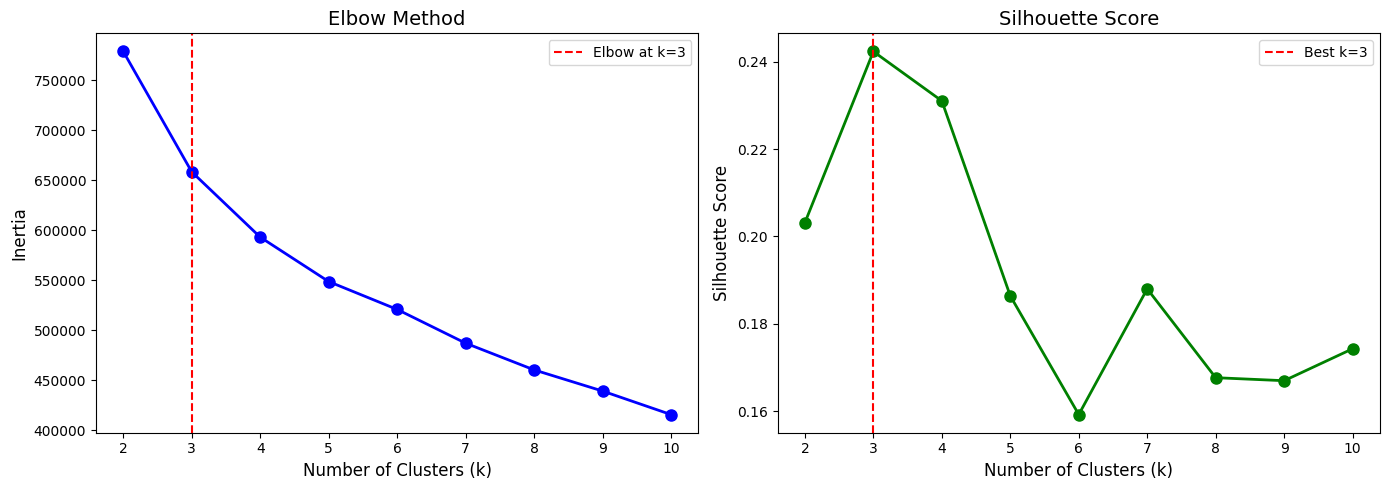

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Method
ax1.plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14)
ax1.axvline(x=3, color='red', linestyle='--', label='Elbow at k=3')
ax1.legend()

# Plot 2: Silhouette Score
ax2.plot(k_range, silhouette_values, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=14)
ax2.axvline(x=3, color='red', linestyle='--', label='Best k=3')
ax2.legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# Train final K-Means with k=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_final.fit(df_scaled)

# Add cluster labels back to original dataframe
df['cluster_kmeans'] = kmeans_final.labels_

# See how many songs landed in each cluster
print("Songs per cluster:")
print(df['cluster_kmeans'].value_counts().sort_index())

# See the mean of each audio feature per cluster
print("\nAverage features per cluster:")
print(df.groupby('cluster_kmeans')[df_features.columns].mean().round(3))

Songs per cluster:
cluster_kmeans
0    12513
1    30807
2    52517
Name: count, dtype: int64

Average features per cluster:
                duration_ms  danceability  energy  loudness  speechiness  \
cluster_kmeans                                                             
0                 97520.590         0.664   0.467   -13.364        0.830   
1                223457.064         0.486   0.311   -13.205        0.060   
2                226592.053         0.627   0.694    -7.606        0.075   

                acousticness  instrumentalness  liveness  valence    tempo  
cluster_kmeans                                                              
0                      0.586             0.001     0.436    0.584  100.389  
1                      0.749             0.169     0.182    0.413  111.940  
2                      0.258             0.051     0.200    0.666  124.911  


In [21]:
from sklearn.cluster import DBSCAN
import collections

dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(df_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = list(dbscan_labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of outliers (-1): {n_outliers}")
print(f"Outlier percentage: {n_outliers/len(df_scaled)*100:.2f}%")
print("\nCluster sizes:")
print(collections.Counter(dbscan_labels))

df['cluster_dbscan'] = dbscan_labels

Number of clusters found: 4
Number of outliers (-1): 1593
Outlier percentage: 1.66%

Cluster sizes:
Counter({np.int64(0): 94170, np.int64(-1): 1593, np.int64(2): 51, np.int64(1): 13, np.int64(3): 10})


In [22]:
# Look at the outlier songs
outliers = df[df['cluster_dbscan'] == -1][['name_song', 'name_artists', 'duration_ms']].head(10)
print("Sample outlier songs:")
print(outliers.to_string(index=False))

Sample outlier songs:
               name_song                name_artists  duration_ms
   Hella Often Freestyle               Old Grape God       822857
     Chanson de ned land                  Jean Gabin        69373
Hell Bound Express Train         Reverend J.M. Gates       178507
     J'attends quelqu'un                      Fréhel       178173
      Vidas Mal Traçadas             Carlos Galhardo       206973
     Sto lofo tou Skouze         Stratos Pagioumtzis       184560
             Tinta Verde                Pedro Maffia       168210
   Chique - Agua Florida                Pedro Maffia       406540
       You're Mine, You! Stan Kenton & His Orchestra       194067
           Collaboration Stan Kenton & His Orchestra       149173


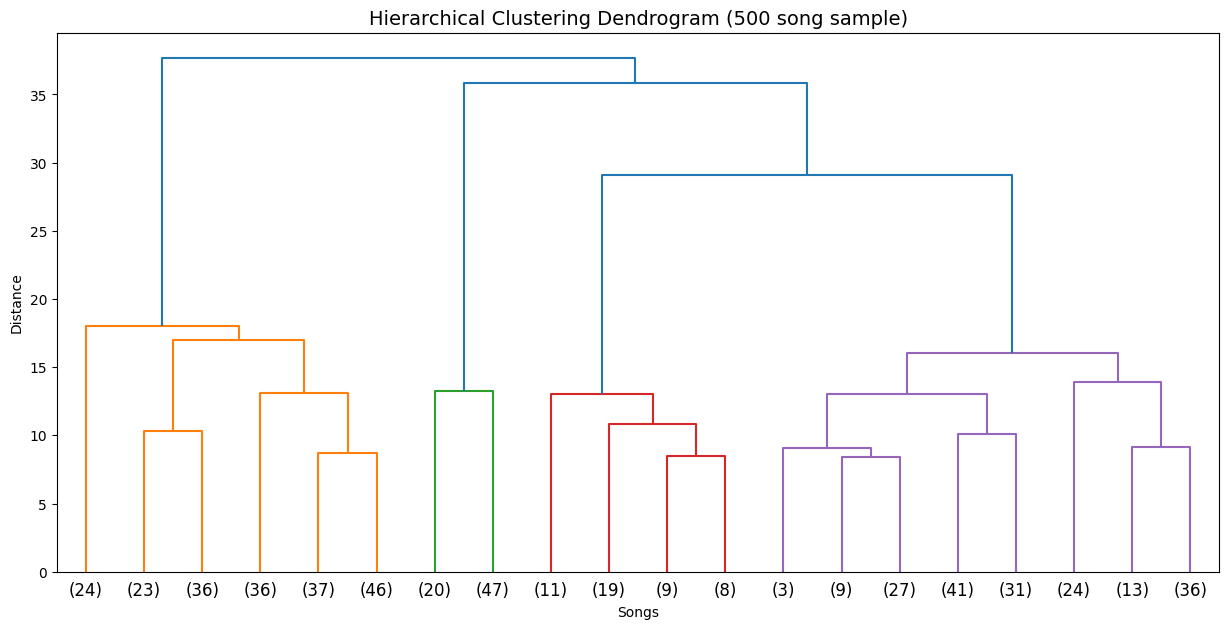

Dendrogram saved!

Hierarchical cluster sizes (10k sample):
Counter({np.int64(0): 5631, np.int64(2): 3150, np.int64(1): 1219})

Hierarchical Silhouette Score: 0.1434


In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# ── Dendrogram on 500 songs ──────────────────────
sample_scaled = df_scaled.sample(500, random_state=42)
linked = linkage(sample_scaled, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram (500 song sample)', fontsize=14)
plt.xlabel('Songs')
plt.ylabel('Distance')
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dendrogram saved!")

# ── Agglomerative on 10,000 songs (not full dataset) ──
sample_10k = df_scaled.sample(10000, random_state=42)
hierarchical = AgglomerativeClustering(n_clusters=3)
hier_labels = hierarchical.fit_predict(sample_10k)

print("\nHierarchical cluster sizes (10k sample):")
print(collections.Counter(hier_labels))

# Save labels for the sample only
df_hier_sample = df.iloc[sample_10k.index].copy()
df_hier_sample['cluster_hierarchical'] = hier_labels

sil_hier = silhouette_score(sample_10k, hier_labels)
print(f"\nHierarchical Silhouette Score: {sil_hier:.4f}")

In [26]:
print("=" * 50)
print("   COMPARISON OF ALL CLUSTERING METHODS")
print("=" * 50)
print(f"K-Means Silhouette      : 0.2423   Best!")
print(f"DBSCAN Silhouette       : Not meaningful (98% in 1 cluster)")
print(f"Hierarchical Silhouette : {sil_hier:.4f}")
print("=" * 50)
print("""
SUMMARY:
- K-Means    → Best for this dataset! Clear 3 clusters
- DBSCAN     → Good at finding outliers (1,593 unusual songs)
              but poor at clustering music overall
- Hierarchical → Confirms 3 clusters but lower silhouette
                 score & memory issues with large data

WINNER: K-Means with k=3 
""")

   COMPARISON OF ALL CLUSTERING METHODS
K-Means Silhouette      : 0.2423   Best!
DBSCAN Silhouette       : Not meaningful (98% in 1 cluster)
Hierarchical Silhouette : 0.1434

SUMMARY:
- K-Means    → Best for this dataset! Clear 3 clusters
- DBSCAN     → Good at finding outliers (1,593 unusual songs)
              but poor at clustering music overall
- Hierarchical → Confirms 3 clusters but lower silhouette
                 score & memory issues with large data

WINNER: K-Means with k=3 



In [27]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(df_scaled, df['cluster_kmeans'])
db_score = davies_bouldin_score(df_scaled, df['cluster_kmeans'])
inertia = kmeans_final.inertia_

print("=" * 40)
print("   CLUSTER EVALUATION METRICS")
print("=" * 40)
print(f"Silhouette Score : {sil_score:.4f}  (higher is better, max=1)")
print(f"Davies-Bouldin   : {db_score:.4f}  (lower is better, min=0)")
print(f"Inertia          : {inertia:.2f}  (lower is better)")
print("=" * 40)
print("""
INTERPRETATION:
- Silhouette 0.24 → Weak but meaningful clusters
  (expected for music data which naturally blends)
- Davies-Bouldin 1.57 → Acceptable separation
- Music genres overlap by nature → these scores are normal!
""")

   CLUSTER EVALUATION METRICS
Silhouette Score : 0.2423  (higher is better, max=1)
Davies-Bouldin   : 1.5702  (lower is better, min=0)
Inertia          : 658335.08  (lower is better)

INTERPRETATION:
- Silhouette 0.24 → Weak but meaningful clusters
  (expected for music data which naturally blends)
- Davies-Bouldin 1.57 → Acceptable separation
- Music genres overlap by nature → these scores are normal!



Variance explained by PC1: 27.08%
Variance explained by PC2: 18.82%
Total variance captured: 45.90%


C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1416527094.py:34: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1416527094.py:34: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1416527094.py:34: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1416527094.py:35: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1416527094.py:35: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1416527094.py:35: UserWarn

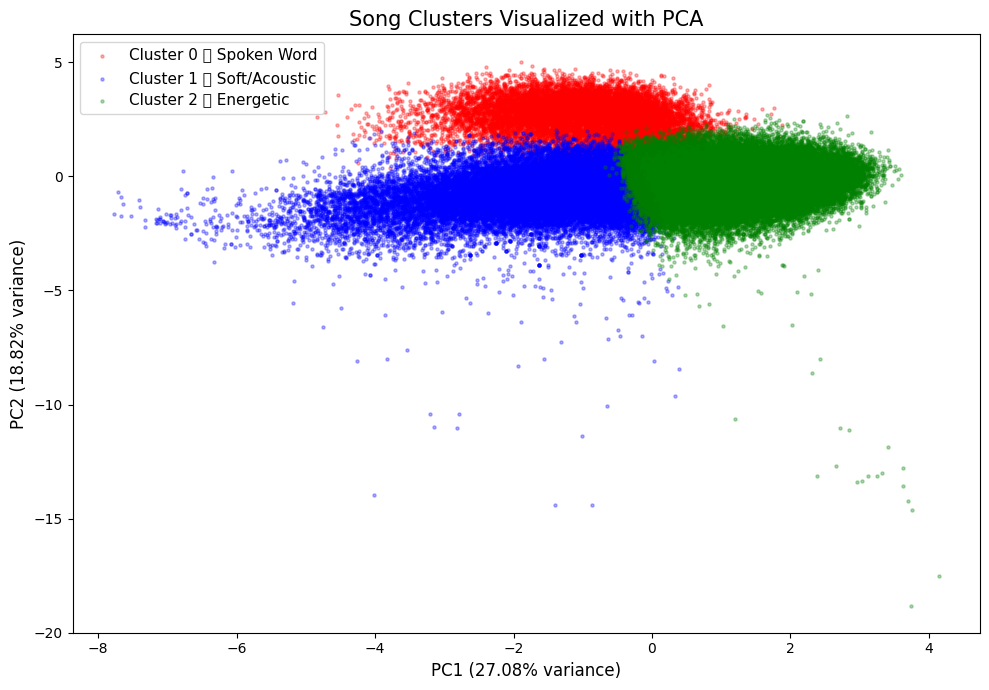

PCA plot saved!


In [28]:
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(df_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance captured: {sum(pca.explained_variance_ratio_):.2%}")

# Plot
plt.figure(figsize=(10, 7))

colors = ['red', 'blue', 'green']
labels = ['Cluster 0 🎙️ Spoken Word', 
          'Cluster 1 🎸 Soft/Acoustic', 
          'Cluster 2 🎉 Energetic']

for cluster_num in range(3):
    mask = df['cluster_kmeans'] == cluster_num
    plt.scatter(
        pca_result[mask, 0],
        pca_result[mask, 1],
        c=colors[cluster_num],
        label=labels[cluster_num],
        alpha=0.3,
        s=5
    )

plt.xlabel('PC1 (27.08% variance)', fontsize=12)
plt.ylabel('PC2 (18.82% variance)', fontsize=12)
plt.title('Song Clusters Visualized with PCA', fontsize=15)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA plot saved!")

c:\Users\craj1\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\craj1\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\craj1\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\398960130.py:21: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight')
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\398960130.py:21: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight

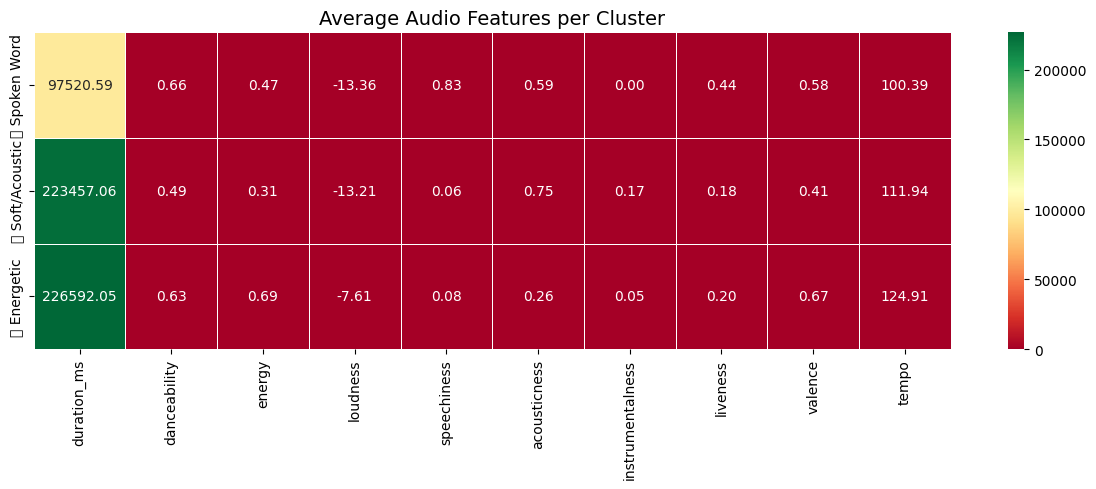

Heatmap saved!


In [31]:
import seaborn as sns

# Calculate mean features per cluster
cluster_means = df.groupby('cluster_kmeans')[df_features.columns].mean()

# Rename index for clarity
cluster_means.index = ['🎙️ Spoken Word', 
                        '🎸 Soft/Acoustic', 
                        '🎉 Energetic']

plt.figure(figsize=(12, 5))
sns.heatmap(
    cluster_means,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5
)
plt.title('Average Audio Features per Cluster', fontsize=14)
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1673957763.py:17: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1673957763.py:17: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1673957763.py:17: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1673957763.py:18: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.savefig('cluster_barcharts.png', dpi=150, bbox_inches='tight')
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1673957763.py:18: UserWarning: Glyph 127928 (\N{GUITAR}) missing from font(s) DejaVu Sans.
  plt.savefig('cluster_barcharts.png', dpi=150, bbox_inches='tight')
C:\Users\craj1\AppData\Local\Temp\ipykernel_25848\1673957763.py:18

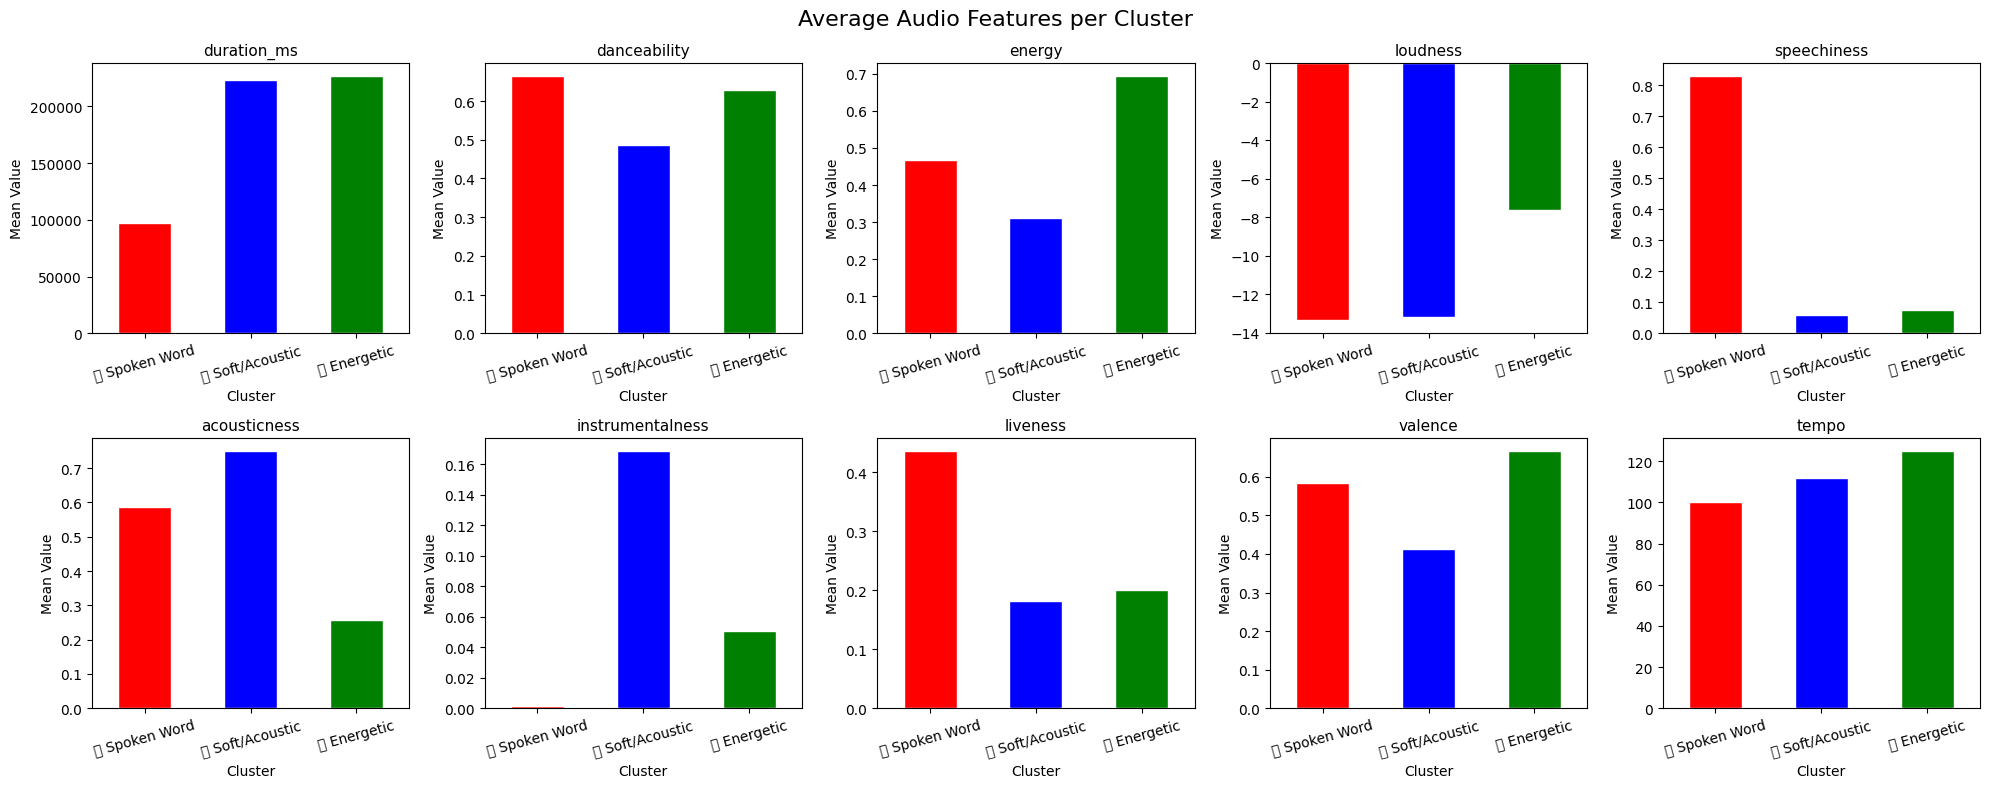

Bar charts saved!


In [32]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(df_features.columns):
    cluster_means[feature].plot(
        kind='bar',
        ax=axes[i],
        color=['red', 'blue', 'green'],
        edgecolor='white'
    )
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Mean Value')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Average Audio Features per Cluster', fontsize=16)
plt.tight_layout()
plt.savefig('cluster_barcharts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar charts saved!")

In [33]:
# Add all cluster labels to final dataframe
final_df = df.copy()

# Rename kmeans cluster for clarity
final_df['cluster_label'] = final_df['cluster_kmeans'].map({
    0: 'Spoken Word',
    1: 'Soft/Acoustic', 
    2: 'Energetic'
})

# Show sample of final dataset
print("Final dataset sample:")
print(final_df[['name_song', 'name_artists', 'cluster_kmeans', 
                 'cluster_label', 'cluster_dbscan']].head(10))

print(f"\nFinal dataset shape: {final_df.shape}")

# Export to CSV
final_df.to_csv('amazon_music_clustered.csv', index=False)
print("\n✅ Final CSV exported: amazon_music_clustered.csv")

Final dataset sample:
          name_song name_artists  cluster_kmeans  cluster_label  \
0           La Java  Mistinguett               1  Soft/Acoustic   
1          En Douce  Mistinguett               1  Soft/Acoustic   
2     J'en Ai Marre  Mistinguett               1  Soft/Acoustic   
3  Ils n'ont pas ca  Mistinguett               1  Soft/Acoustic   
4         La belote  Mistinguett               1  Soft/Acoustic   
5   Oh mademoiselle  Mistinguett               1  Soft/Acoustic   
6    Il m'a vue nue  Mistinguett               1  Soft/Acoustic   
7      Mon Bus'ness  Mistinguett               1  Soft/Acoustic   
8    Ça c'est Paris  Mistinguett               1  Soft/Acoustic   
9           Le Fado  Mistinguett               1  Soft/Acoustic   

   cluster_dbscan  
0               0  
1               0  
2               0  
3               0  
4               0  
5               0  
6               0  
7               0  
8               0  
9               0  

Final dataset shape